In [1]:
print("Heart Disease Prediction Project")

Heart Disease Prediction Project


In [2]:
import pandas as pd

df = pd.read_csv("../dataset/heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [6]:
df.info

<bound method DataFrame.info of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.shape

(1025, 14)

In [9]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [10]:
df.duplicated().sum()

np.int64(723)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [12]:
df = pd.read_csv("../dataset/heart.csv")

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [14]:
print("Shape:", df.shape)

Shape: (1025, 14)


In [15]:
print("Columns:")
print(df.columns)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [17]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [18]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Unique rows:", df.drop_duplicates().shape[0])

Total rows: 1025
Duplicate rows: 723
Unique rows: 302


In [19]:
df = df.drop_duplicates().reset_index(drop=True)

In [20]:
print("New shape:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

New shape: (302, 14)
Duplicates remaining: 0


In [21]:
df = df.drop_duplicates().reset_index(drop=True)

print("New shape:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

New shape: (302, 14)
Duplicates remaining: 0


In [22]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [23]:
df["target"].value_counts(normalize=True) * 100

target
1    54.304636
0    45.695364
Name: proportion, dtype: float64

In [25]:

df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [26]:
# ==========================================
# STEP 7: PREPARE DATA FOR MACHINE LEARNING
# ==========================================

# Separate input features (X) and target (y)
X = df.drop("target", axis=1)
y = df["target"]

# Display the shapes
print("Input features shape:", X.shape)
print("Target shape:", y.shape)

# Display the feature names
print("\nFeatures:")
print(X.columns.tolist())

# Display target distribution
print("\nTarget distribution:")
print(y.value_counts())

# Display target percentages
print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Input features shape: (302, 13)
Target shape: (302,)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target distribution:
target
1    164
0    138
Name: count, dtype: int64

Target percentage:
target
1    54.3
0    45.7
Name: proportion, dtype: float64


In [27]:
# ==========================================
# STEP 8: TRAIN / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the sizes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)


# ==========================================
# FEATURE SCALING
# ==========================================

scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("\nScaling completed successfully.")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Training features: (241, 13)
Testing features: (61, 13)
Training target: (241,)
Testing target: (61,)

Scaling completed successfully.
Scaled training data shape: (241, 13)
Scaled testing data shape: (61, 13)


In [28]:
# ==========================================
# STEP 9: LOGISTIC REGRESSION
# ==========================================

from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")


# ==========================================
# MAKE PREDICTIONS
# ==========================================

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions created successfully.")

# Display first 10 predictions
print("\nFirst 10 predictions:")
print(y_pred_logistic[:10])

# Display first 10 actual values
print("\nFirst 10 actual values:")
print(y_test.values[:10])

Logistic Regression model trained successfully.
Predictions created successfully.

First 10 predictions:
[0 1 0 1 1 0 1 0 1 1]

First 10 actual values:
[0 0 0 0 0 0 1 0 1 0]


In [29]:
# ==========================================
# STEP 10: EVALUATE LOGISTIC REGRESSION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

# Display results
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 40)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# Classification report
print("\nClassification Report")
print("=" * 40)
print(classification_report(y_test, y_pred_logistic))

LOGISTIC REGRESSION PERFORMANCE
Accuracy  : 0.8033
Precision : 0.8000
Recall    : 0.8485
F1 Score  : 0.8235

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



Confusion Matrix:
[[21  7]
 [ 5 28]]


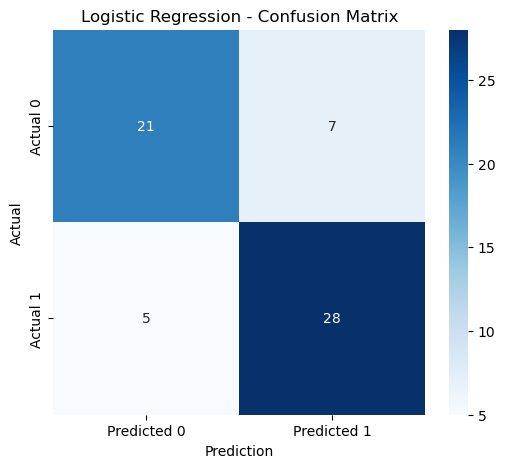

In [30]:
# ==========================================
# STEP 11: CONFUSION MATRIX
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

In [31]:
# ==========================================
# STEP 12: DECISION TREE
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully.")


# ==========================================
# MAKE PREDICTIONS
# ==========================================

y_pred_tree = decision_tree.predict(X_test)

print("Predictions created successfully.")


# ==========================================
# EVALUATE MODEL
# ==========================================

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("\nDECISION TREE PERFORMANCE")
print("=" * 40)

print(f"Accuracy  : {tree_accuracy:.4f}")
print(f"Precision : {tree_precision:.4f}")
print(f"Recall    : {tree_recall:.4f}")
print(f"F1 Score  : {tree_f1:.4f}")


# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report")
print("=" * 40)

print(classification_report(y_test, y_pred_tree))

Decision Tree model trained successfully.
Predictions created successfully.

DECISION TREE PERFORMANCE
Accuracy  : 0.8033
Precision : 0.8182
Recall    : 0.8182
F1 Score  : 0.8182

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [32]:
X_train
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
24,61,0,0,145,307,0,0,146,1,1.0,1,0,3
59,59,1,3,170,288,0,0,159,0,0.2,1,0,3
257,67,1,0,120,229,0,0,129,1,2.6,1,2,3
54,67,1,2,152,212,0,0,150,0,0.8,1,0,3
40,61,0,0,130,330,0,0,169,0,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
36,64,1,0,128,263,0,1,105,1,0.2,1,1,3
17,50,0,1,120,244,0,1,162,0,1.1,2,0,2
105,61,1,0,120,260,0,1,140,1,3.6,1,1,3
66,56,1,0,125,249,1,0,144,1,1.2,1,1,2


In [33]:
X_train_scaled
X_test_scaled

array([[ 7.55666977e-01, -1.44559455e+00, -9.54280751e-01,
         8.16146540e-01,  1.10397589e+00, -3.98313753e-01,
        -1.00805864e+00, -2.14736984e-01,  1.53206469e+00,
         3.98071192e-03, -6.97127354e-01, -7.22716350e-01,
         1.07583844e+00],
       [ 5.33574610e-01,  6.91756899e-01,  1.95687951e+00,
         2.30713590e+00,  7.50669654e-01, -3.98313753e-01,
        -1.00805864e+00,  3.63741924e-01, -6.52713952e-01,
        -6.93729522e-01, -6.97127354e-01, -7.22716350e-01,
         1.07583844e+00],
       [ 1.42194408e+00,  6.91756899e-01, -9.54280751e-01,
        -6.74842818e-01, -3.46439176e-01, -3.98313753e-01,
        -1.00805864e+00, -9.71209401e-01,  1.53206469e+00,
         1.39940118e+00, -6.97127354e-01,  1.18083163e+00,
         1.07583844e+00],
       [ 1.42194408e+00,  6.91756899e-01,  9.86492759e-01,
         1.23362356e+00, -6.62555280e-01, -3.98313753e-01,
        -1.00805864e+00, -3.67434735e-02, -6.52713952e-01,
        -1.70446847e-01, -6.97127354e

Decision Tree Confusion Matrix:
[[22  6]
 [ 6 27]]


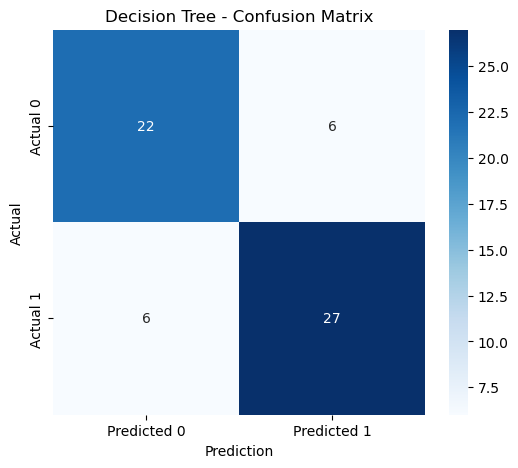

In [34]:
# ==========================================
# STEP 13: DECISION TREE CONFUSION MATRIX
# ==========================================

cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(cm_tree)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

In [35]:
# ==========================================
# STEP 14: RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully.")


# ==========================================
# MAKE PREDICTIONS
# ==========================================

y_pred_rf = random_forest.predict(X_test)

print("Predictions created successfully.")


# ==========================================
# EVALUATE MODEL
# ==========================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("\nRANDOM FOREST PERFORMANCE")
print("=" * 40)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")


# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report")
print("=" * 40)

print(classification_report(y_test, y_pred_rf))

Random Forest model trained successfully.
Predictions created successfully.

RANDOM FOREST PERFORMANCE
Accuracy  : 0.7541
Precision : 0.7647
Recall    : 0.7879
F1 Score  : 0.7761

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



Random Forest Confusion Matrix:
[[20  8]
 [ 7 26]]


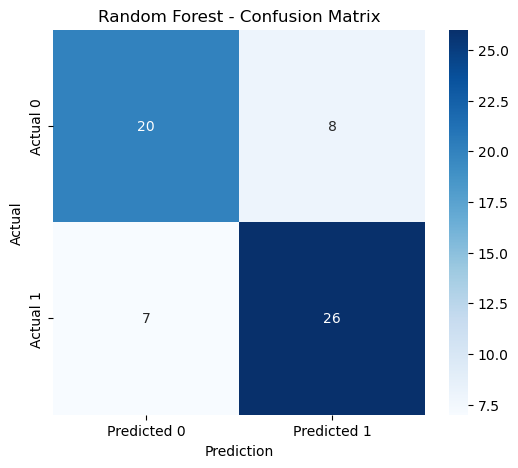

In [36]:
# ==========================================
# STEP 15: RANDOM FOREST CONFUSION MATRIX
# ==========================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

In [37]:
# ==========================================
# STEP 16: MODEL COMPARISON
# ==========================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy,
        tree_accuracy,
        rf_accuracy
    ],

    "Precision": [
        precision,
        tree_precision,
        rf_precision
    ],

    "Recall": [
        recall,
        tree_recall,
        rf_recall
    ],

    "F1 Score": [
        f1,
        tree_f1,
        rf_f1
    ]
})

# Round the values
results = results.round(4)

# Display comparison
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8033,0.8000,0.8485,0.8235
1,Decision Tree,0.8033,0.8182,0.8182,0.8182
2,Random Forest,0.7541,0.7647,0.7879,0.7761


Feature Importance:


,Feature,Importance
0,cp,0.173969
1,thalach,0.131634
2,ca,0.105700
3,oldpeak,0.096577
4,thal,0.090418
5,age,0.083049
6,exang,0.073679
7,trestbps,0.072088
8,chol,0.067384
9,sex,0.040229


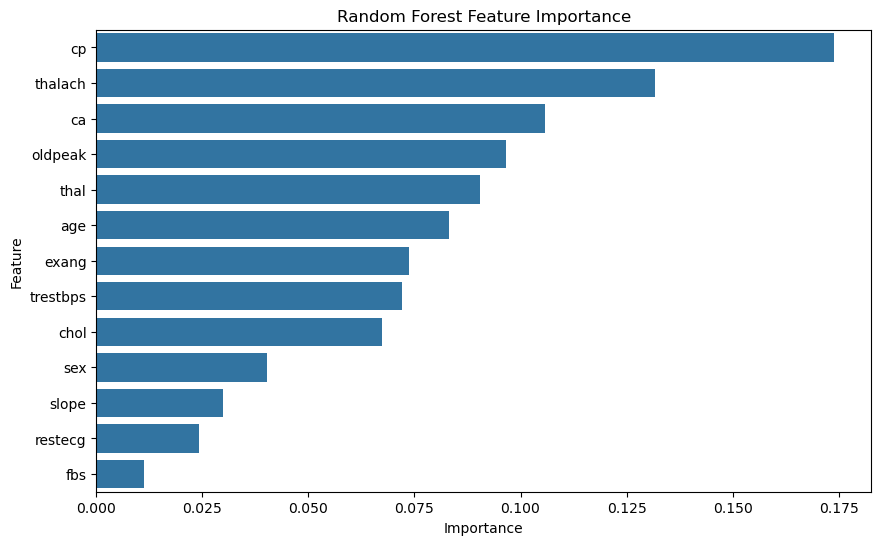

In [38]:
# ==========================================
# STEP 17: FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Feature Importance:")
display(feature_importance)


# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [39]:
# ==========================================
# STEP 18: SAVE MODEL AND SCALER
# ==========================================

import joblib
import os

# Make sure the models folder exists
os.makedirs("../models", exist_ok=True)

# Save the Logistic Regression model
joblib.dump(
    logistic_model,
    "../models/heart_model.pkl"
)

# Save the scaler
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Model and scaler saved successfully!")

# Check whether the files exist
print("\nModel file exists:",
      os.path.exists("../models/heart_model.pkl"))

print("Scaler file exists:",
      os.path.exists("../models/scaler.pkl"))

Model and scaler saved successfully!

Model file exists: True
Scaler file exists: True


In [40]:
# ==========================================
# STEP 19: TEST SAVED MODEL
# ==========================================

# Load the saved model
loaded_model = joblib.load(
    "../models/heart_model.pkl"
)

# Load the saved scaler
loaded_scaler = joblib.load(
    "../models/scaler.pkl"
)

print("Model loaded successfully!")
print("Scaler loaded successfully!")


# Test using one record from the test dataset
sample = X_test.iloc[[0]]

# Scale the sample
sample_scaled = loaded_scaler.transform(sample)

# Make prediction
prediction = loaded_model.predict(sample_scaled)

# Get probability
probability = loaded_model.predict_proba(sample_scaled)

print("\nSample input:")
display(sample)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

Model loaded successfully!
Scaler loaded successfully!

Sample input:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
24,61,0,0,145,307,0,0,146,1,1.0,1,0,3


Prediction: 0
Probability: [0.81460259 0.18539741]
